In [ ]:
preprocess_file(r'/home/eman/signly/data/og_sentences_dataset.txt', '/home/eman/signly/data/og_sentences_nlp_processed.txt')

Processing /home/eman/signly/data/og_sentences_dataset.txt through nlp_utils
transform_to_arsl received: 'بندق اشترى السيارة أمس.'
DEBUG arsl_sequence before N-gram: ['بندق', 'قبل', 'ٱشترى', 'سيارة', 'أمس', '.']
transform_to_arsl received: 'الصديقان ذهبا إلى العقبة في عطلة نهاية الأسبوع.'
DEBUG arsl_sequence before N-gram: ['اثنان', 'صديق', 'ذهب', 'عقبة', 'عطلة', 'نهاية', 'أسبوع', '.']
transform_to_arsl received: 'لأن الطقس حار شربت الماء.'
DEBUG arsl_sequence before N-gram: ['أن', 'طقس', 'حار', 'قبل', 'شرب', 'ماء', '.']
transform_to_arsl received: 'سمسم أكل السوق صباحاً.'
DEBUG arsl_sequence before N-gram: ['سمسم', 'قبل', 'أكل', 'سوق', 'صباح', '.']
transform_to_arsl received: 'شرب سمسم التفاحة أمس.'
DEBUG arsl_sequence before N-gram: ['قبل', 'شرب', 'سمسم', 'تفاح', 'أمس', '.']
transform_to_arsl received: 'ليو كتب العصير صباحاً.'
DEBUG arsl_sequence before N-gram: ['يو', 'قبل', 'كتب', 'عصير', 'صباح', '.']
transform_to_arsl received: 'زار لوز الكاميرا صباحاً.'
DEBUG arsl_sequence before 

loaded environment variables from: /home/eman/signly/backend/.env
Processing /home/eman/signly/data/KArSL_corpus/train-ar.txt through nlp_utils
transform_to_arsl received: 'استخدام الغازات في الحروب يسبب السرطان'
DEBUG arsl_sequence before N-gram: ['ٱستخدام', 'كثير', 'غاز', 'حرب', 'سبب', 'سرطان']
transform_to_arsl received: 'قال الطبيب أن معي بكتيريا في الجلد'
DEBUG arsl_sequence before N-gram: ['قبل', 'قال', 'طبيب', 'معي', 'بكتيريا', 'جلد']
transform_to_arsl received: 'يتم تطعيم الأطفال بعد سن الثانية'
DEBUG arsl_sequence before N-gram: ['تم', 'تطعيم', 'كثير', 'طفل', 'بعد', 'سن', 'ثاني']
transform_to_arsl received: 'عانى المريض من تورم في الساقين'
DEBUG arsl_sequence before N-gram: ['قبل', 'عانى', 'مريض', 'قبل', 'تورم', 'اثنان', 'ساق']
transform_to_arsl received: 'متى لاحظت وجود هذا الورم'
DEBUG arsl_sequence before N-gram: ['قبل', 'لاحظ', 'وجود', 'هذا', 'ورم']
transform_to_arsl received: 'هل يمكن أن ألد ولادة طبيعية وانا حامل بتوأم؟'
DEBUG arsl_sequence before N-gram: ['أمكن', 'ولد',

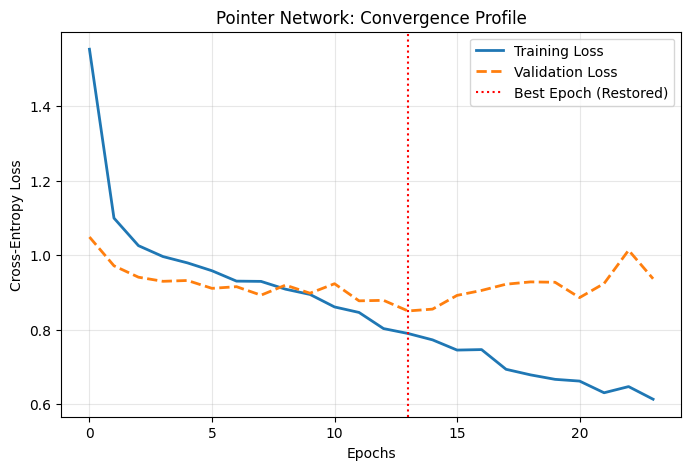


Inference Running on 90 Aligned Test Sequences
Example 1:
Source (NLP) : قبل اصيبت بنت إعاقة سمعي قبل جاء
Target (ArSL): قبل البنت اصابة إعاقة سمعية فجأة
Prediction   : قبل بنت إعاقة اصيبت سمعي جاء قبل
--------------------------------------------------
Example 2:
Source (NLP) : تطعيم منع ٱنتشار شلل كثير طفل
Target (ArSL): التطعيم منع انتشار شلل طفل طفل طفل
Prediction   : تطعيم ٱنتشار شلل كثير طفل منع
--------------------------------------------------
Example 3:
Source (NLP) : ٱنتشر سم جسم بعد ساعة
Target (ArSL): بعد ساعة السم انتشار في أنت جسم
Prediction   : ٱنتشر بعد جسم ساعة سم
--------------------------------------------------
Example 4:
Source (NLP) : منع كبد سم ٱنتشار دم
Target (ArSL): الكبد وقف السم انتشار في الدم
Prediction   : منع كبد سم دم ٱنتشار
--------------------------------------------------
Example 5:
Source (NLP) : ذهب كثير طارئة أخذ إبرة
Target (ArSL): أنت ذهب إلى الطوارئ السبب أخذ إبرة
Prediction   : ذهب كثير أخذ إبرة طارئة
-------------------------------------------

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from scipy import stats
import sys
from dotenv import load_dotenv

current_dir = os.path.abspath(os.getcwd())
root_dir = current_dir

while root_dir and not os.path.exists(os.path.join(root_dir, 'backend')):
    parent = os.path.dirname(root_dir)
    if parent == root_dir:
        break
    root_dir = parent

backend_dir = os.path.join(root_dir, 'backend')

env_path_root = os.path.join(root_dir, '.env')
env_path_backend = os.path.join(backend_dir, '.env')

if os.path.exists(env_path_root):
    load_dotenv(dotenv_path=env_path_root)
    print(f"loaded environment variables from: {env_path_root}")
elif os.path.exists(env_path_backend):
    load_dotenv(dotenv_path=env_path_backend)
    print(f"loaded environment variables from: {env_path_backend}")

if os.path.exists(backend_dir):
    if backend_dir not in sys.path:
        sys.path.append(backend_dir)
else:
    print(f"CRITICAL ERROR: Could not find backend directory starting from {current_dir}")

from app.core.nlp_utils import transform_to_arsl

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_MODEL = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2').to(DEVICE)
HIDDEN_DIM = 512
LR = 1e-3
BATCH_SIZE = 16
MAX_LEN = 20
NUM_EPOCHS = 80

WEIGHT_DECAY = 1e-4  # L2
DROPOUT_RATE = 0.3   
PATIENCE = 10

DATA_DIR = os.path.join(root_dir, 'data', 'KArSL_corpus')

# TEST PATHS 
PATH_TEST_AR = os.path.join(DATA_DIR, 'test-ar.txt')
PATH_TEST_NLP_OUT = os.path.join(DATA_DIR, 'test-ar-nlp-processed.txt')
PATH_TEST_TARGET = os.path.join(DATA_DIR, 'ArSL-ts01-glossed%2BProcessed.txt')

# TRAIN PATHS 
PATH_TRAIN_AR = os.path.join(DATA_DIR, 'train-ar.txt') 
PATH_TRAIN_NLP_OUT = os.path.join(DATA_DIR, 'train-ar-nlp-processed.txt')
PATH_TRAIN_TARGET = os.path.join(DATA_DIR, 'ArSL-tr01-glossed%2BProcessed.txt')

# VAL PATHS
PATH_VAL_AR = os.path.join(DATA_DIR, 'validation-ar.txt') 
PATH_VAL_NLP_OUT = os.path.join(DATA_DIR, 'val-ar-nlp-processed.txt')
PATH_VAL_TARGET = os.path.join(DATA_DIR, 'ArSL-val01-glossed%2BProcessed.txt')


def preprocess_file(source_path, dest_path):
    """Processes raw Arabic text through the NLP pipeline and saves it."""
    if not os.path.exists(source_path):
        print(f"Warning: Source text file not found at: {source_path}. Skipping preprocessing.")
        return
        
    print(f"Processing {source_path} through nlp_utils")
    processed_lines = []
    with open(source_path, 'r', encoding='utf-8') as f:
        raw_lines = [line.strip() for line in f if line.strip()]
        
    for idx, line in enumerate(raw_lines):
        gloss_list = transform_to_arsl(line)
        processed_line = " ".join(gloss_list)
        processed_lines.append(processed_line)
        
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    with open(dest_path, 'w', encoding='utf-8') as f:
        for line in processed_lines:
            f.write(line + "\n")
            
    print(f"Saved pipeline outputs to: {dest_path}\n")

def load_aligned_data(src_path, tgt_path):
    """Loads aligned parallel data. Removed set() deduplication to preserve alignment."""
    if not os.path.exists(src_path) or not os.path.exists(tgt_path):
        raise FileNotFoundError(f"Missing files! Src: {src_path} | Tgt: {tgt_path}")
        
    with open(src_path, 'r', encoding='utf-8') as f:
        src_lines = [l.strip() for l in f if l.strip()]
    with open(tgt_path, 'r', encoding='utf-8') as f:
        tgt_lines = [l.strip() for l in f if l.strip()]
    
    assert len(src_lines) == len(tgt_lines), f"Mismatched dataset lengths in {src_path}. Src: {len(src_lines)}, Tgt: {len(tgt_lines)}"
    return src_lines, tgt_lines

class PointerDataset(Dataset):
    def __init__(self, src_lines, tgt_lines):
        # Now explicitly requires both source and target lines
        self.src_lines = src_lines
        self.tgt_lines = tgt_lines

    def __len__(self): 
        return len(self.src_lines)

    def __getitem__(self, idx):
        source_words = self.src_lines[idx].split()[:MAX_LEN]
        target_words = self.tgt_lines[idx].split()[:MAX_LEN]

        # Shuffling the source words ruins the semantic meaning of the sentence 
        # for an RNN sequence-to-sequence translation task. 

        target_indices = []
        for word in target_words:
            if word in source_words:
                target_indices.append(source_words.index(word))
            else:
                target_indices.append(0) # Pad fallback index for out-of-vocab target words

        embeddings = EMBED_MODEL.encode(source_words)
        padded_embeds = np.zeros((MAX_LEN, 384))
        padded_embeds[:len(source_words)] = embeddings

        padded_targets = np.full(MAX_LEN, -1)
        padded_targets[:len(target_indices)] = target_indices

        return torch.FloatTensor(padded_embeds), torch.LongTensor(padded_targets), len(source_words)

# ptr net
class PointerAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.vt = nn.Linear(hidden_dim, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        out = torch.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden).unsqueeze(1))
        scores = self.vt(out).squeeze(2)
        return scores

class PointerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.attention = PointerAttention(hidden_dim)
        self.reduce_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.reduce_c = nn.Linear(hidden_dim * 2, hidden_dim)
        
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        x = self.dropout(x)
        
        enc_out, (h_n, c_n) = self.encoder(x)
        enc_out = self.dropout(enc_out)

        h_d = self.reduce_h(torch.cat((h_n[0], h_n[1]), dim=1)).unsqueeze(0)
        c_d = self.reduce_c(torch.cat((c_n[0], c_n[1]), dim=1)).unsqueeze(0)

        enc_out_reduced = enc_out[:, :, :HIDDEN_DIM] + enc_out[:, :, HIDDEN_DIM:]
        all_logits = []
        decoder_input = torch.zeros(batch_size, 1, HIDDEN_DIM).to(DEVICE)

        for _ in range(seq_len):
            _, (h_d, c_d) = self.decoder(decoder_input, (h_d, c_d))
            h_d_dropped = self.dropout(h_d)
            logits = self.attention(h_d_dropped.squeeze(0), enc_out_reduced)
            all_logits.append(logits)

        return torch.stack(all_logits, dim=1)

def train_and_validate(train_loader, val_loader, patience=PATIENCE):
    model = PointerNet(384, HIDDEN_DIM).to(DEVICE)
    
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    
    history = {'train_loss': [], 'val_loss': []}

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = None

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, _ in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                output = model(x)
                loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
                val_loss += loss.item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == NUM_EPOCHS - 1 or patience_counter >= patience:
            print(f"Epoch [{epoch:02d}/{NUM_EPOCHS-1}] -> Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n[!] Early stopping triggered at epoch {epoch}!")
            print(f"Restoring best model weights (Validation Loss: {best_val_loss:.4f})")
            break
     
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    # Plotting (best epoch)
    best_epoch_idx = len(history['val_loss']) - patience_counter - 1
    
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Training Loss', lw=2)
    plt.plot(history['val_loss'], label='Validation Loss', lw=2, linestyle='--')
    
    if best_epoch_idx >= 0:
        plt.axvline(x=best_epoch_idx, color='r', linestyle=':', label='Best Epoch (Restored)')
        
    plt.title("Pointer Network: Convergence Profile")
    plt.xlabel("Epochs")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return model

def compute_bootstrap_ci(metrics_list, confidence=0.95, n_resamples=1000):
    means = []
    for _ in range(n_resamples):
        sample = random.choices(metrics_list, k=len(metrics_list))
        means.append(np.mean(sample))
    lower = np.percentile(means, ((1 - confidence) / 2) * 100)
    upper = np.percentile(means, (1 - (1 - confidence) / 2) * 100)
    return np.mean(metrics_list), lower, upper

def evaluate_on_test_set(model, src_lines, tgt_lines):
    model.eval()
    smooth_fn = SmoothingFunction().method1
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

    bleu_scores = []
    rouge_scores = []
    exact_matches = []

    print(f"\nInference Running on {len(src_lines)} Aligned Test Sequences")
    
    # a file to save the predictions for manual review
    inspection_path = os.path.join(root_dir, 'predictions_inspection.txt')
    inspection_file = open(inspection_path, "w", encoding="utf-8")
    
    with torch.no_grad():
        for i, (src_sent, tgt_sent) in enumerate(zip(src_lines, tgt_lines)):
            src_words = src_sent.split()[:MAX_LEN]
            n = len(src_words)
            if n == 0: continue
            
            emb = torch.FloatTensor(EMBED_MODEL.encode(src_words)).unsqueeze(0).to(DEVICE)
            padded_x = torch.zeros(1, MAX_LEN, 384).to(DEVICE)
            padded_x[0, :n] = emb
            logits = model(padded_x)[0]

            indices = []
            mask = torch.zeros(n).to(DEVICE)
            for step in range(n):
                step_logits = logits[step, :n] + mask
                idx = torch.argmax(step_logits).item()
                indices.append(idx)
                mask[idx] = -1e9

            predicted_words = [src_words[idx] for idx in indices]
            pred_sent = " ".join(predicted_words)
            ref_words = tgt_sent.split()

            log_text = (
                f"Example {i+1}:\n"
                f"Source (NLP) : {src_sent}\n"
                f"Target (ArSL): {tgt_sent}\n"
                f"Prediction   : {pred_sent}\n"
                f"{'-'*50}\n"
            )
            inspection_file.write(log_text)
            
            # Print the first 5 to the console for quick viewing
            if i < 5:
                print(log_text.strip())

            # Metrics calculation
            b_score = sentence_bleu([ref_words], predicted_words, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth_fn)
            r_score = scorer.score(tgt_sent, pred_sent)['rougeL'].fmeasure
            em_score = 1.0 if pred_sent.strip() == tgt_sent.strip() else 0.0

            bleu_scores.append(b_score)
            rouge_scores.append(r_score)
            exact_matches.append(em_score)

    inspection_file.close()
    print(f"\n[!] Saved full prediction log to '{inspection_path}' for manual review.")
    
    mean_bleu, b_low, b_high = compute_bootstrap_ci(bleu_scores)
    mean_rouge, r_low, r_high = compute_bootstrap_ci(rouge_scores)
    mean_em, em_low, em_high = compute_bootstrap_ci(exact_matches)

    print("\n" + "="*60)
    print("Evaluation Metrics")
    print("="*60)
    print(f"{'Metric':<15} | {'Mean Value':<12} | {'95% Confidence Interval (CI)':<30}")
    print("-"*60)
    print(f"{'BLEU-4':<15} | {mean_bleu*100:<12.2f}% | [{b_low*100:.2f}%, {b_high*100:.2f}%]")
    print(f"{'ROUGE-L':<15} | {mean_rouge*100:<12.2f}% | [{r_low*100:.2f}%, {r_high*100:.2f}%]")
    print(f"{'Exact Match':<15} | {mean_em*100:<12.2f}% | [{em_low*100:.2f}%, {em_high*100:.2f}%]")
    print("="*60 + "\n")

if __name__ == "__main__":
    
    preprocess_file(PATH_TRAIN_AR, PATH_TRAIN_NLP_OUT)
    preprocess_file(PATH_VAL_AR, PATH_VAL_NLP_OUT)
    preprocess_file(PATH_TEST_AR, PATH_TEST_NLP_OUT)

    train_src_lines, train_tgt_lines = load_aligned_data(PATH_TRAIN_NLP_OUT, PATH_TRAIN_TARGET)
    val_src_lines, val_tgt_lines = load_aligned_data(PATH_VAL_NLP_OUT, PATH_VAL_TARGET)
    test_src_lines, test_tgt_lines = load_aligned_data(PATH_TEST_NLP_OUT, PATH_TEST_TARGET)

    train_ds = PointerDataset(train_src_lines, train_tgt_lines)
    val_ds = PointerDataset(val_src_lines, val_tgt_lines)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    trained_model = train_and_validate(train_loader, val_loader)

    evaluate_on_test_set(trained_model, test_src_lines, test_tgt_lines)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training on 510 sentences...
Epoch [0/79], Loss: 1.8958
Epoch [10/79], Loss: 1.4823
Epoch [20/79], Loss: 1.2200
Epoch [30/79], Loss: 0.9160
Epoch [40/79], Loss: 0.5599
Epoch [50/79], Loss: 0.2797
Epoch [60/79], Loss: 0.1267
Epoch [70/79], Loss: 0.0569
Epoch [79/79], Loss: 0.0226


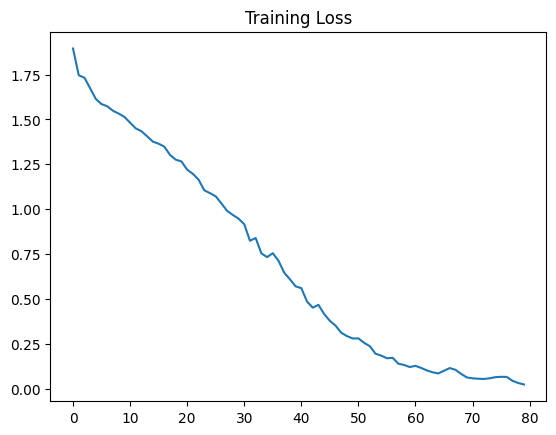

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sentence_transformers import SentenceTransformer
import numpy as np
import random
import matplotlib.pyplot as plt
### TODO: tr, val, ts files should be put through implemented nlp then the output should be input to
### the ptr net aligned with tr0x, val0x, ts0x and compared as the other side of the split
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMBED_MODEL = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2').to(DEVICE)
HIDDEN_DIM = 512
LR = 1e-3
BATCH_SIZE = 16
MAX_LEN = 20

class PointerAttention(nn.Module):# Bi-LSTM Pointer Network
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.vt = nn.Linear(hidden_dim, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        # encoder_outputs: [batch, seq_len, hidden_dim]
        # decoder_hidden: [batch, hidden_dim]
        out = torch.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden).unsqueeze(1))
        scores = self.vt(out).squeeze(2)
        return scores

class PointerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.attention = PointerAttention(hidden_dim)


        self.reduce_h = nn.Linear(hidden_dim * 2, hidden_dim) # Project Bi-LSTM (2 * hidden) back to decoder size (hidden)
        self.reduce_c = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        enc_out, (h_n, c_n) = self.encoder(x)

        # Prepare initial decoder state
        h_d = self.reduce_h(torch.cat((h_n[0], h_n[1]), dim=1)).unsqueeze(0)
        c_d = self.reduce_c(torch.cat((c_n[0], c_n[1]), dim=1)).unsqueeze(0)

        # Sum bidirectional outputs for attention key
        enc_out_reduced = enc_out[:, :, :HIDDEN_DIM] + enc_out[:, :, HIDDEN_DIM:]

        all_logits = []
        decoder_input = torch.zeros(batch_size, 1, HIDDEN_DIM).to(DEVICE)

        for _ in range(seq_len):
            _, (h_d, c_d) = self.decoder(decoder_input, (h_d, c_d))
            logits = self.attention(h_d.squeeze(0), enc_out_reduced)
            all_logits.append(logits)

        return torch.stack(all_logits, dim=1) # [batch, seq_len, seq_len]

all_files = [
    "/content/ArSL-tr01-glossed+Processed.txt",
    #"/content/ArSL-tr02-glossed+Processed.txt",
    "/content/ArSL-val01-glossed+Processed.txt"
    #"/content/ArSL-val02-glossed+Processed.txt"
]

combined_lines = []
for f_path in all_files:
    try:
        with open(f_path, 'r', encoding="utf-8") as f:
            combined_lines.extend([l.strip() for l in f if l.strip()])
    except FileNotFoundError:
        print(f"File missing: {f_path}")

class MegaDataset(Dataset):
    def __init__(self, lines, augment=True):
        self.lines = list(set(lines)) # De-duplicate
        self.augment = augment

    def __len__(self): return len(self.lines)

    def __getitem__(self, idx):
        line_words = self.lines[idx].split()[:MAX_LEN]
        target_words = list(line_words)
        source_words = list(line_words)

        if self.augment:
            random.shuffle(source_words)

        target_indices = []
        for word in target_words:
            if word in source_words:
                target_indices.append(source_words.index(word))
            else:
                target_indices.append(0)

        embeddings = EMBED_MODEL.encode(source_words)
        padded_embeds = np.zeros((MAX_LEN, 384))
        padded_embeds[:len(source_words)] = embeddings

        padded_targets = np.full(MAX_LEN, -1)
        padded_targets[:len(target_indices)] = target_indices

        return torch.FloatTensor(padded_embeds), torch.LongTensor(padded_targets), len(source_words)

def train_ptr_net(train_loader, num_epochs=80):
    model = PointerNet(384, HIDDEN_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_history = []

    print(f"Training on {len(combined_lines)} sentences")
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch [{epoch}/{num_epochs-1}], Loss: {avg_loss:.4f}")

    plt.plot(loss_history)
    plt.title("Training Loss")
    plt.show()
    return model

def reorder_sentence_hybrid(model, sentence):
    particles = ["قبل" ,"اثنان" ,"كثير" ,"في", "و", "على", "من", "إلى", "عن", "ثم"]
    words = sentence.split()
    glued = []
    i = 0
    while i < len(words):
        if words[i] in particles and i + 1 < len(words):
            glued.append(f"{words[i]}_{words[i+1]}")
            i += 2
        else:
            glued.append(words[i])
            i += 1

    clean_glued = [w.replace("؟", "").replace("!", "") for w in glued]
    n = len(clean_glued)

    model.eval()
    with torch.no_grad():
        emb = torch.FloatTensor(EMBED_MODEL.encode(clean_glued)).unsqueeze(0).to(DEVICE)
        padded_x = torch.zeros(1, MAX_LEN, 384).to(DEVICE)
        padded_x[0, :n] = emb
        logits = model(padded_x)[0]

        indices = []
        mask = torch.zeros(n).to(DEVICE)
        for step in range(n):
            step_logits = logits[step, :n] + mask
            idx = torch.argmax(step_logits).item()
            indices.append(idx)
            mask[idx] = -1e9

        reordered = [clean_glued[idx] for idx in indices]

    final = " ".join(reordered).replace("_", " ")

    if "؟" in sentence:
        final = "؟ " + final

    return final

mega_ds = MegaDataset(combined_lines, augment=True)
loader = DataLoader(mega_ds, batch_size=BATCH_SIZE, shuffle=True)

model = train_ptr_net(loader, num_epochs=80)


In [14]:
torch.save(model.state_dict(), "pointer_net_arsl.pth")

print(reorder_sentence_hybrid(model, "أين غرفة المعيشة؟"))

؟ غرفة المعيشة أين


In [15]:
print(reorder_sentence_hybrid(model, "فنجان قهوة"))

فنجان قهوة
